# Evaluation
In this notebook we evaluate the event detection quality on a manually annotated news dataset.

In [ ]:
import pandas as pd
from ast import literal_eval
import matplotlib.pyplot as plt
import json

from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import f1_score, hamming_loss, accuracy_score, precision_score, recall_score

In [37]:
with open("event_jsons/new_events_with_ids.json") as f:
    events = json.load(f)


MAP = {}

for event in events:
    MAP[event["event_id"]] = event["text"]
    
MAP

{'2001_0': 'Wikipedia is launched.',
 '2001_1': 'President Joseph Estrada of the Philippines is ousted in the Second EDSA Revolution.',
 '2001_2': 'George W. Bush is inaugurated as President of the United States.',
 '2001_3': 'An earthquake strikes Gujarat, India, on Republic Day, resulting in more than 20,000 deaths.',
 '2001_4': 'Twenty tourists are abducted by the Abu Sayyaf Group terrorists from a popular island resort in the Philippines.',
 '2001_5': 'Eleven members of the royal family of Nepal, including the king and queen, are killed by Crown Prince Dipendra, who wounds himself and dies three days later.',
 '2001_6': 'Nineteen Al-Qaeda terrorists hijack four planes, crashing two into the twin towers of the World Trade Center in New York City, the third plane into the Pentagon in Washington, DC, while the fourth plane is downed on the outskirts of Stonycreek Township, Pennsylvania. 2,996 people, including 2,977 victims and 19 hijackers, die in the attacks.',
 '2001_7': 'The Unite

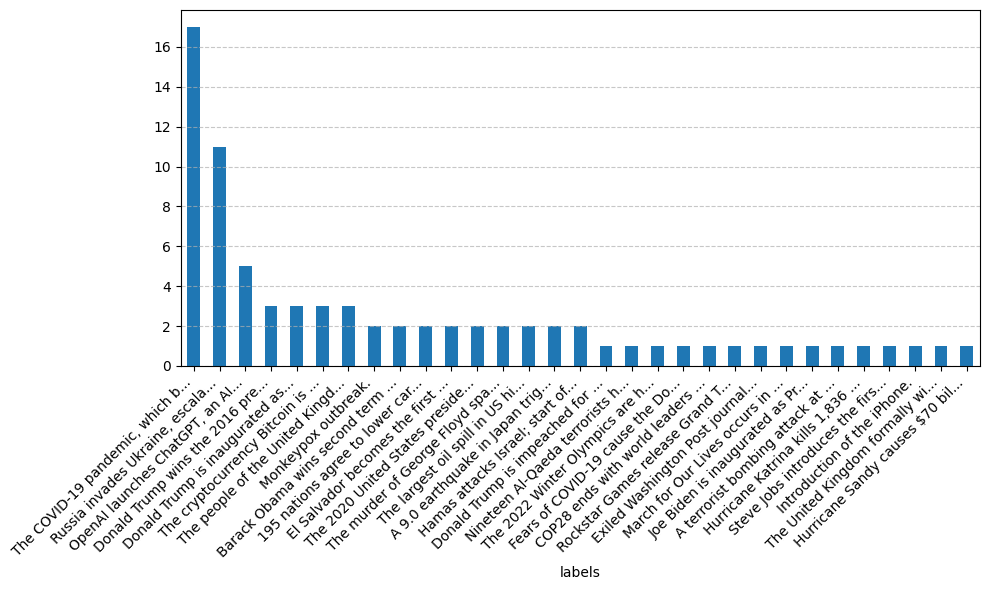

In [38]:
def truncate_label(label, max_length=15):
    return label if len(label) <= max_length else label[:max_length] + "..."

plt.figure(figsize=(10, 6))

counts = df["labels"].explode().value_counts().rename(index=MAP)
counts.index = counts.index.map(lambda x: truncate_label(str(x), max_length=30))
counts.plot(kind="bar")

plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout() 
plt.show()

### General metrics

In [40]:
eval_dataset = pd.read_csv("eval_dataset.csv", sep="\t",index_col=0)
eval_dataset["labels"] = eval_dataset["labels"].apply(literal_eval)
eval_dataset["prediction"] = eval_dataset["prediction"].apply(literal_eval)
eval_dataset

,news_id,labels,prediction
0,23219,[2022_39],[2022_39]
1,23223,[2020_40],[2020_40]
2,23230,[2022_11],[2022_11]
3,23246,[2012_5],[2012_5]
4,23253,"[2016_11, 2015_7, 2017_0]","[2016_11, 2017_0]"
5,23254,"[2012_5, 2016_11, 2017_0]","[2008_3, 2016_11, 2017_0]"
6,23354,[2020_40],"[2002_12, 2020_40]"
7,23364,[2022_5],"[2013_13, 2022_5]"
8,23369,[],[2002_8]
9,23440,[2009_0],[2009_0]


In [41]:
all_labels = sorted({lbl for sublist in eval_dataset["labels"] for lbl in sublist} |
                    {lbl for sublist in eval_dataset["prediction"] for lbl in sublist})

mlb = MultiLabelBinarizer(classes=all_labels)

Y_true = mlb.fit_transform(eval_dataset["labels"])
Y_pred = mlb.transform(eval_dataset["prediction"])

micro_precision = precision_score(Y_true, Y_pred, average="micro", zero_division=0)
micro_recall = recall_score(Y_true, Y_pred, average="micro", zero_division=0)
micro_f1 = f1_score(Y_true, Y_pred, average="micro", zero_division=0)
hamming = hamming_loss(Y_true, Y_pred)
subset_acc = accuracy_score(Y_true, Y_pred)  # exact match

macro_precision = precision_score(Y_true, Y_pred, average="macro", zero_division=0)
macro_recall = recall_score(Y_true, Y_pred, average="macro", zero_division=0)
macro_f1 = f1_score(Y_true, Y_pred, average="macro", zero_division=0)

per_label_precision = precision_score(Y_true, Y_pred, average=None, zero_division=0)
per_label_recall = recall_score(Y_true, Y_pred, average=None, zero_division=0)
per_label_f1 = f1_score(Y_true, Y_pred, average=None, zero_division=0)

per_label_df = pd.DataFrame({
    "Label": all_labels,
    "Precision": per_label_precision,
    "Recall": per_label_recall,
    "F1": per_label_f1
})

per_label_df = per_label_df.sort_values(by="F1", ascending=False)

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)

print(f"Micro Precision: {micro_precision:.4f}")
print(f"Micro Recall: {micro_recall:.4f}")
print(f"Micro F1: {micro_f1:.4f}")

print(f"Macro Precision: {macro_precision:.4f}")
print(f"Macro Recall: {macro_recall:.4f}")
print(f"Macro F1: {macro_f1:.4f}")

print(f"Hamming Loss: {hamming:.4f}")
print(f"Exact Match Accuracy: {subset_acc:.4f}")

per_label_df


Micro Precision: 0.6941
Micro Recall: 0.7564
Micro F1: 0.7239
Macro Precision: 0.5480
Macro Recall: 0.5223
Macro F1: 0.5235
Hamming Loss: 0.0111
Exact Match Accuracy: 0.6364


,Label,Precision,Recall,F1
1,2001_8,1.000000,1.000000,1.000000
40,2023_28,1.000000,1.000000,1.000000
37,2022_4,1.000000,1.000000,1.000000
27,2020_29,1.000000,1.000000,1.000000
21,2016_11,1.000000,1.000000,1.000000
23,2017_0,1.000000,1.000000,1.000000
24,2017_4,1.000000,1.000000,1.000000
15,2013_10,1.000000,1.000000,1.000000
11,2010_4,1.000000,1.000000,1.000000
36,2022_39,1.000000,1.000000,1.000000
